In [1]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]
Python executable: /Users/sadiquenomani/traceback-phase1/venv/bin/python


In [2]:
from deepface import DeepFace

print("DeepFace imported successfully!")

DeepFace imported successfully!


# Missing Person Finder — Face Verification

## Project Objective

The main objective of this project is to develop a Missing Person Finder application
using face recognition technology.

The system will use facial features extracted from images to identify potential
matches for a missing person from a database of registered individuals.

### Current Phase

In this phase, we are developing and evaluating the face recognition component
using the ArcFace model through DeepFace.

The first task is **face verification**, where two face images are compared to
determine whether they belong to the same person.

### Workflow

1. Load two face images.
2. Detect faces in the images.
3. Generate facial representations using ArcFace.
4. Calculate the distance between the representations.
5. Compare the distance with a predefined threshold.
6. Determine whether the two images are a potential match.

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace

print("All required libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All required libraries imported successfully!


In [ ]:
image1_path = "photo1.jpg"
image2_path = "photo2.jpg" 

image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)

print("Image 1 loaded:", image1 is not None)
print("Image 2 loaded:", image2 is not None)

print("Image 1 shape:", image1.shape if image1 is not None else None)
print("Image 2 shape:", image2.shape if image2 is not None else None)

Image 1 loaded: True
Image 2 loaded: True
Image 1 shape: (413, 413, 3)
Image 2 shape: (1529, 1336, 3)


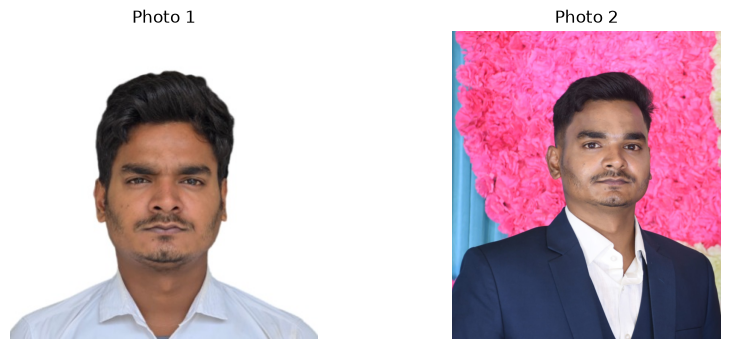

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.title("Photo 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
plt.title("Photo 2")
plt.axis("off")

plt.show()

# Face Verification Architecture

The following architecture represents the current face verification pipeline
used as the foundation for the Missing Person Finder system.

```text
┌──────────────────────┐
│    Input Image 1     │
│      photo1.jpg      │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│    Face Detection    │
│   OpenCV Detector    │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│   ArcFace Model      │
│  Feature Extraction  │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│   512-D Embedding    │
│    Face Vector 1     │
└──────────┬───────────┘
           │
           │
           │       ┌──────────────────────┐
           │       │    Input Image 2     │
           │       │      photo2.jpg      │
           │       └──────────┬───────────┘
           │                  │
           │                  ▼
           │       ┌──────────────────────┐
           │       │    Face Detection    │
           │       │   OpenCV Detector    │
           │       └──────────┬───────────┘
           │                  │
           │                  ▼
           │       ┌──────────────────────┐
           │       │    ArcFace Model     │
           │       │  Feature Extraction  │
           │       └──────────┬───────────┘
           │                  │
           │                  ▼
           │       ┌──────────────────────┐
           │       │   512-D Embedding    │
           │       │    Face Vector 2      │
           │       └──────────┬───────────┘
           │                  │
           └──────────┬───────┘
                      ▼
            ┌─────────────────────┐
            │  Cosine Similarity  │
            │  / Cosine Distance  │
            └──────────┬──────────┘
                       │
                       ▼
            ┌─────────────────────┐
            │  Threshold = 0.68   │
            └──────────┬──────────┘
                       │
                       ▼
              ┌─────────────────┐
              │ Verification     │
              │     Result       │
              └───────┬─────────┘
                      / \
                     /   \
                    ▼     ▼
             SAME PERSON  DIFFERENT

In [7]:
faces1 = DeepFace.extract_faces(
    img_path=image1_path,
    detector_backend="opencv",
    enforce_detection=True
)

faces2 = DeepFace.extract_faces(
    img_path=image2_path,
    detector_backend="opencv",
    enforce_detection=True
)

print("Faces detected in Photo 1:", len(faces1))
print("Faces detected in Photo 2:", len(faces2))

Faces detected in Photo 1: 1
Faces detected in Photo 2: 1


In [8]:
embedding1 = DeepFace.represent(
    img_path=image1_path,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

embedding2 = DeepFace.represent(
    img_path=image2_path,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

vector1 = np.array(embedding1[0]["embedding"])
vector2 = np.array(embedding2[0]["embedding"])

print("Embedding 1 shape:", vector1.shape)
print("Embedding 2 shape:", vector2.shape)
print("Embedding 1 type:", vector1.dtype)

Embedding 1 shape: (512,)
Embedding 2 shape: (512,)
Embedding 1 type: float64


In [9]:
cosine_similarity = np.dot(vector1, vector2) / (
    np.linalg.norm(vector1) * np.linalg.norm(vector2)
)

cosine_distance = 1 - cosine_similarity

print("Cosine similarity:", round(cosine_similarity, 4))
print("Cosine distance:", round(cosine_distance, 4))

Cosine similarity: 0.656
Cosine distance: 0.344


In [10]:
threshold = 0.68

if cosine_distance <= threshold:
    result = "SAME PERSON"
else:
    result = "DIFFERENT PEOPLE"

print("Cosine distance:", round(cosine_distance, 4))
print("Threshold:", threshold)
print("Result:", result)

Cosine distance: 0.344
Threshold: 0.68
Result: SAME PERSON


## 10. Conclusion

In this experiment, two face images were processed using the ArcFace face recognition model.

The system:

- Detected the face in both images.
- Generated a 512-dimensional facial embedding for each image.
- Calculated cosine similarity and cosine distance between the embeddings.
- Compared the cosine distance with the selected threshold of 0.68.
- Classified the two images as belonging to the same person.

The obtained cosine distance was 0.344, which is below the threshold of 0.68.

This face verification component will serve as the foundation for the next stage of the project: **one-to-many face identification**, where a query image will be compared against multiple people in a face database to identify potential matches.

In [11]:
import os

dataset_dir = "deepface_repo/tests/unit/dataset"
csv_path = os.path.join(dataset_dir, "master.csv")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Benchmark CSV exists:", os.path.exists(csv_path))
print("CSV path:", csv_path)

Dataset exists: True
Benchmark CSV exists: True
CSV path: deepface_repo/tests/unit/dataset/master.csv


In [12]:
import pandas as pd

master_df = pd.read_csv(csv_path)

print("Number of benchmark pairs:", len(master_df))
print("\nColumns:")
print(master_df.columns.tolist())

print("\nFirst 5 pairs:")
display(master_df.head())

Number of benchmark pairs: 300

Columns:
['file_x', 'file_y', 'Decision']

First 5 pairs:


,file_x,file_y,Decision
0,img20.jpg,img21.jpg,Yes
1,img16.jpg,img17.jpg,Yes
2,img3.jpg,img12.jpg,Yes
3,img22.jpg,img23.jpg,Yes
4,img24.jpg,img25.jpg,Yes


In [13]:
print("Decision distribution:")
print(master_df["Decision"].value_counts())

Decision distribution:
Decision
No     262
Yes     38
Name: count, dtype: int64


In [14]:
first_pair = master_df.iloc[0]

print("Image 1:", first_pair["file_x"])
print("Image 2:", first_pair["file_y"])
print("Expected:", first_pair["Decision"])

Image 1: img20.jpg
Image 2: img21.jpg
Expected: Yes


In [15]:
test_image1 = os.path.join(dataset_dir, first_pair["file_x"])
test_image2 = os.path.join(dataset_dir, first_pair["file_y"])

verification = DeepFace.verify(
    img1_path=test_image1,
    img2_path=test_image2,
    model_name="ArcFace",
    detector_backend="opencv",
    enforce_detection=True
)

print("Image 1:", first_pair["file_x"])
print("Image 2:", first_pair["file_y"])
print("Expected:", first_pair["Decision"])
print("Predicted:", "Yes" if verification["verified"] else "No")
print("Distance:", round(verification["distance"], 4))
print("Threshold:", verification["threshold"])

Image 1: img20.jpg
Image 2: img21.jpg
Expected: Yes
Predicted: Yes
Distance: 0.2622
Threshold: 0.68


In [16]:
import time

correct = 0
incorrect = 0
errors = 0

start_time = time.time()

for index, row in master_df.iterrows():

    image1 = os.path.join(dataset_dir, row["file_x"])
    image2 = os.path.join(dataset_dir, row["file_y"])

    try:
        verification = DeepFace.verify(
            img1_path=image1,
            img2_path=image2,
            model_name="ArcFace",
            detector_backend="opencv",
            enforce_detection=True
        )

        predicted = "Yes" if verification["verified"] else "No"
        expected = row["Decision"]

        if predicted == expected:
            correct += 1
        else:
            incorrect += 1

    except Exception as e:
        errors += 1
        print(f"Error in pair {index}: {e}")

elapsed_time = time.time() - start_time

total_tested = correct + incorrect

print("==============================")
print("      BENCHMARK RESULTS")
print("==============================")
print(f"Total pairs:     {len(master_df)}")
print(f"Correct:         {correct}")
print(f"Incorrect:       {incorrect}")
print(f"Errors:          {errors}")
print(f"Tested:          {total_tested}")

if total_tested > 0:
    accuracy = (correct / total_tested) * 100
    print(f"Accuracy:        {accuracy:.2f}%")

print(f"Total time:      {elapsed_time:.1f} seconds")
print(f"Time per pair:   {elapsed_time / len(master_df):.2f} seconds")

      BENCHMARK RESULTS
Total pairs:     300
Correct:         300
Incorrect:       0
Errors:          0
Tested:          300
Accuracy:        100.00%
Total time:      267.2 seconds
Time per pair:   0.89 seconds


# Benchmark Architecture

The benchmark evaluates the ArcFace face verification pipeline on
multiple image pairs.

```text
              Benchmark Dataset
                     │
                     ▼
              Image Pair (A, B)
                     │
          ┌──────────┴──────────┐
          ▼                     ▼
     Face Detection        Face Detection
          │                     │
          ▼                     ▼
       ArcFace               ArcFace
          │                     │
          ▼                     ▼
    512-D Embedding       512-D Embedding
          │                     │
          └──────────┬──────────┘
                     ▼
             Cosine Distance
                     │
                     ▼
              ArcFace Threshold
                     │
                     ▼
          ┌──────────┴──────────┐
          ▼                     ▼
       SAME PERSON         DIFFERENT PEOPLE
          │                     │
          └──────────┬──────────┘
                     ▼
             Compare with
             Expected Label
                     │
                     ▼
              Accuracy Result

## Benchmark Results

The ArcFace face verification model was evaluated on the complete benchmark
dataset containing 300 image pairs.

### Results

- **Total pairs:** 300
- **Correct predictions:** 300
- **Incorrect predictions:** 0
- **Errors:** 0
- **Accuracy:** 100.00%
- **Total execution time:** 267.2 seconds
- **Average time per pair:** 0.89 seconds

### Observation

The system correctly classified all 300 benchmark pairs in this experiment.
This demonstrates that the implemented ArcFace-based face verification pipeline
performed successfully on the selected benchmark dataset.

However, this result should not be interpreted as 100% real-world accuracy.
Performance on real-world missing-person images may differ because of factors
such as image quality, lighting, pose, age variation, occlusion, and other
conditions.

### Conclusion

The benchmark confirms that the current face verification pipeline is working
correctly and provides a suitable foundation for the next stage of the project:
**one-to-many face identification and missing-person search.**